In [1]:
from ucimlrepo import fetch_ucirepo 
import random
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
import os

# Fuzzy C-Means (T1)

In [2]:
# 1° Passo - Montar Matriz W com sorteio
def matriz_w(X, clusters):
    W = []

    # Teremos que fazer o sorteio de 'clusters' valores 150 vezes (tamanho da iris)
    for linha in range(len(X)):
        # Gerando 'clusters' números aleatórios
        prob = [random.random() for _ in range(clusters)]

        # Transformando em entre 0 e 1 (percentual)
        prob_normalizados = [x / sum(prob) for x in prob]
        
        W.append(prob_normalizados)
        
    W = pd.DataFrame(W, columns=[f'C{i}' for i in range(1, clusters + 1)])
    return W 

# 2° Passo - Calcular o centróide dos cluster
def calcular_centroides(X, W):
    # Pegando a variável xi (todos valores do df)
    xi = X.values
    
    centroides = []
    
    for col in W.columns:
        pesos = W[col].values
        
        # Aplicando a fórmula
        numerador = np.sum(xi * pesos[:, None], axis=0)
        denominador = np.sum(pesos)
        
        centroides.append(numerador / denominador)
    
    return np.array(centroides)

# 3° Passo - Atualizar pesos

# Função de distância Euclidiana
def dist(a, b):
    return np.linalg.norm(a - b)

# Função para atualizar os pesos
def att_pesos(centroides, X, m):
    novos_pesos = []
    # Pra cada linha, atualizaremos os pesos
    for _, linha in X.iterrows():
        # Extraindo os valores da linha
        xi = linha.values
        
        # Calculando a distância de cada centroide para essa linha
        distancias = [dist(xi, c) for c in centroides]
        
        probabilidade_att = []
        for d in distancias:
            # Se a distância for 0, o peso é 1
            if np.any(d == 0):
                probabilidade_att.append(1.0)
            else:
                soma_razões = sum([(d / d_2)**(2/(m-1)) for d_2 in distancias])
                probabilidade_att.append(1 / soma_razões)
                
        novos_pesos.append(probabilidade_att)

    # Atualizando a matriz W com os novos pesos calculados
    W = pd.DataFrame(novos_pesos, columns=[f'C{i+1}' for i in range(len(centroides))])
    return W


# 4° Passo - Função para classificar amostras

# Função para dar uma classe a partir de uma diff comparada com o threshold
# O threshold funcionará como um valor mínimo da diferença entre os clusters com maior probabilidade
def classificacao(W, threshold):
    classe = []
    
    for _, row in W.iterrows():
        valores = row.values
        
        # Ordena do maior pro menor para calcular a diff
        ordenados = np.sort(valores)[::-1]
        
        maior = ordenados[0]
        segundo = ordenados[1]
        
        diff = maior - segundo
        
        idx_max = valores.argmax()
        
        # Se a diff foi 'suficiente', classificamos
        if diff >= threshold:
            classe.append(f'cluster{idx_max}')
        else:
            classe.append('ruido')
    
    return np.array(classe)

# 5° Passo - Função final (mesclando tudo)

# Teremos um número máximo de iterações, mas ele poderá parar antes conforme o critério de parada pré-determinado  <----------------------
def fuzzy_c_means(X, clusters, threshold, m, max_iter=100):
    # Normalizando os valores de X usando min max
    scaler = MinMaxScaler()
    
    # Normalizando e voltando pra df
    X_norm = pd.DataFrame(
        scaler.fit_transform(X),
        columns=X.columns,
        index=X.index
    )
    
    centroides = []
    
    # Criando a matriz W
    W = matriz_w(X_norm, clusters)
    
    # Looping até atingir o critério de parada ou o máximo de iterações fornecido
    for i in range(max_iter):
        centroide_atual = calcular_centroides(X_norm, W)
        W = att_pesos(centroide_atual, X_norm, m)
        centroides.append(centroide_atual)

        # Critério de parada: se a diferença entre os centróides atuais e os anteriores for menor que 10^-3 e i != 0 (não tem valor para comparar na 1° iteração), então paramos
        if (i != 0) and (np.max(np.abs(np.array(centroides[-1]) - np.array(centroides[-2]))) < 1e-3):
            print(f'    Critério de parada atingido, com {i} iterações')
            break
        
    # Classificaremos através de um threshold que funcionará como um valor mínimo da diferença entre os clusters com maior probabilidade, os que não passarem receberão cluster 'ruido'
    y = classificacao(W, threshold)
    
    # Calcularemos também o Silhouette como métrica de avaliação
    # Primeiro é preciso tirar as classes ruído
    X_sem_ruido = X_norm[y != 'ruido']
    W_sem_ruido = W[y != 'ruido']
    
    # Verificar número de clusters válidos
    labels = W_sem_ruido.values.argmax(axis=1)
    labels_unicos = np.unique(labels)

    # Se não tiver classificado ninguém ou tiver apenas um cluster, silhouette é -1, caso contrário aplica o silhouette de fato
    if len(X_sem_ruido) == 0 or len(labels_unicos) < 2:
        silhouette = -1
    else: 
        silhouette = silhouette_score(X_sem_ruido, labels)
    
    return np.array(centroides), W, y, silhouette

# Processamento Dados Brutos

In [3]:
# https://www.kaggle.com/datasets/christofferms/pokemon-with-stats-and-image?resource=download
spark = SparkSession.builder.appName("Pokedex").getOrCreate()

# Leitura
df = spark.read.csv("pokedex_bruta.csv", header=True, inferSchema=True)

# Drop
df = df.drop("Image")

# Rename
df = (
    df.withColumnRenamed("Index", "num_pokedex")
      .withColumnRenamed("Name", "name")
      .withColumnRenamed("Type 1", "type_1")
      .withColumnRenamed("Type 2", "type_2")
      .withColumnRenamed("Total", "total")
      .withColumnRenamed("HP", "hp")
      .withColumnRenamed("Attack", "attack")
      .withColumnRenamed("Defense", "defense")
      .withColumnRenamed("SP. Atk.", "sp_atk")
      .withColumnRenamed("SP. Def", "sp_def")
      .withColumnRenamed("Speed", "speed")
)
# Dropando as variações por regiões Alola, Gallar, Hisui e forma Mega
df = df.dropDuplicates(["num_pokedex"])

In [4]:
df.show()

+-----------+----------+------+------+-----+---+------+-------+------+------+-----+
|num_pokedex|      name|type_1|type_2|total| hp|attack|defense|sp_atk|sp_def|speed|
+-----------+----------+------+------+-----+---+------+-------+------+------+-----+
|          1| Bulbasaur| Grass|Poison|  318| 45|    49|     49|    65|    65|   45|
|          2|   Ivysaur| Grass|Poison|  405| 60|    62|     63|    80|    80|   60|
|          3|  Venusaur| Grass|Poison|  525| 80|    82|     83|   100|   100|   80|
|          4|Charmander|  Fire|  NULL|  309| 39|    52|     43|    60|    50|   65|
|          5|Charmeleon|  Fire|  NULL|  405| 58|    64|     58|    80|    65|   80|
|          6| Charizard|  Fire|Flying|  534| 78|    84|     78|   109|    85|  100|
|          7|  Squirtle| Water|  NULL|  314| 44|    48|     65|    50|    64|   43|
|          8| Wartortle| Water|  NULL|  405| 59|    63|     80|    65|    80|   58|
|          9| Blastoise| Water|  NULL|  530| 79|    83|    100|    85|   105

In [ ]:
# https://www.kaggle.com/datasets/christofferms/pokemon-with-stats-and-image?resource=download
'''df = pd.read_csv('pokedex_bruta.csv')

# Dropando colunas que não serão utilizadas
df = df.drop(['Image'], axis=1)

df = df.rename(columns = {'Index':'num_pokedex', 'Name':'name', 'Type 1':'type_1', 'Type 2':'type_2', 'Total':'total', 'HP':'hp', 'Attack':'attack',
       'Defense':'defense', 'SP. Atk.':'sp_atk', 'SP. Def':'sp_def', 'Speed':'speed'})

df.to_csv('pokedex.csv', index=False)'''
# Type 1 e 2 --> 18

In [ ]:
# Fazendo a versão sem as variações por regiões Alola, Gallar, Hisui e forma Mega
'''df = pd.read_csv('pokedex.csv')
df = df.drop_duplicates(subset=['num_pokedex'])
df.to_csv('pokedex_filtrada.csv', index=False)'''

# Algoritmo de Agrupamento

In [ ]:
'''df = pd.read_csv('pokedex_filtrada.csv')
df.columns'''

Index(['num_pokedex', 'name', 'type_1', 'type_2', 'total', 'hp', 'attack',
       'defense', 'sp_atk', 'sp_def', 'speed'],
      dtype='object')

In [8]:
# Usaremos o Fuzzy C-Means aplicado no T1
#df = pd.read_csv('pokedex_filtrada.csv')
X = df.select('total', 'hp', 'attack','defense', 'sp_atk','sp_def', 'speed')

# Convertendo X para pandas pq assim a função funcionará
X = X.toPandas()

# Definindo os parâmetros
threshold = 0.65
qtd_cluster = 5
max_iter = 200
coefs_silhouette = []

# Variaremos o m de 1.1 a 3 de 0.1 em 0.1 para determinal qual a melhor opção através do coef silhouette e quantidade de ruídos
ms = np.arange(1.1, 3.1, 0.1).round(1)

# Variaremos o m conforme a lista
for m in ms:
    cent, W, y, silhouette = fuzzy_c_means(X, qtd_cluster, threshold, m, max_iter)
    
    # Adicionando a classificação a matriz W
    W['Class'] = y
    
    # Salvado algumas variáveis para avaliação
    n = len(W)
    ruido = len(W[W['Class'] == 'ruido'])
    prop_ruido = ruido / n

    # Ponderando a quantidade de ruído junto ao coeficiente de silhouette
    score = silhouette * (1 - prop_ruido)
    coefs_silhouette.append([m, ruido, silhouette, score]) 

    print(f"        m = {m} | Ruídos = {ruido} | Silhouette = {silhouette:.4f} | Score: {score:.4f}")

# Depois de rodar todos, precisamos bater o martelo para o melhor, nesse caso usando o coeficiente silhouette combinado com o ruído (score)
melhor = max(coefs_silhouette, key=lambda x: x[3])
melhor_m = melhor[0]
melhor_ruido = melhor[1]
melhor_silhouette = melhor[2]
melhor_score = melhor[3]

# Salvando as variáveis finais
print(f'\n\nDito isso, m = {melhor_m} apresentou o melhor coeficiente silhouette combinado com o ruído ({melhor_score:.4f})')

# Aplicando o modelo final com os melhores hiperparâmetros
cent, W, y, silhouette = fuzzy_c_means(X, qtd_cluster, threshold, melhor_m, max_iter)

    Critério de parada atingido, com 59 iterações
        m = 1.1 | Ruídos = 95 | Silhouette = 0.2902 | Score: 0.2633
    Critério de parada atingido, com 23 iterações
        m = 1.2 | Ruídos = 215 | Silhouette = 0.2820 | Score: 0.2228
    Critério de parada atingido, com 35 iterações
        m = 1.3 | Ruídos = 360 | Silhouette = 0.3136 | Score: 0.2034
    Critério de parada atingido, com 30 iterações
        m = 1.4 | Ruídos = 532 | Silhouette = 0.3361 | Score: 0.1616
    Critério de parada atingido, com 36 iterações
        m = 1.5 | Ruídos = 704 | Silhouette = 0.3347 | Score: 0.1048
    Critério de parada atingido, com 18 iterações
        m = 1.6 | Ruídos = 764 | Silhouette = 0.3873 | Score: 0.0986
    Critério de parada atingido, com 32 iterações
        m = 1.7 | Ruídos = 823 | Silhouette = 0.4044 | Score: 0.0797
    Critério de parada atingido, com 49 iterações
        m = 1.8 | Ruídos = 884 | Silhouette = -1.0000 | Score: -0.1376
    Critério de parada atingido, com 3 iteraçõe

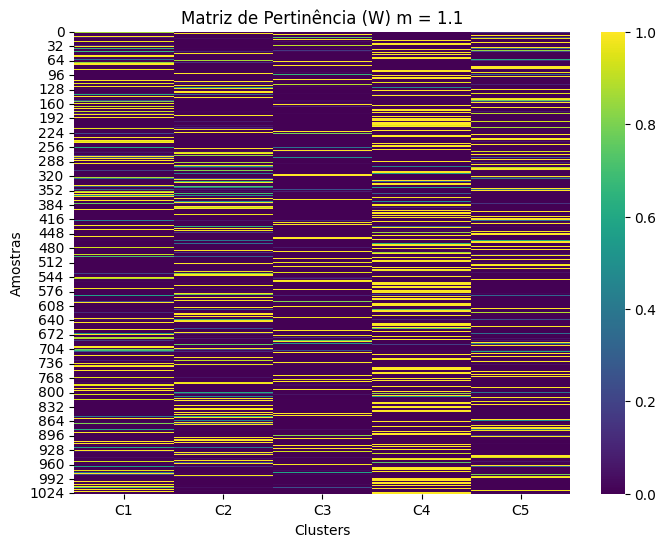

In [9]:
# Mostrando a pertinência através de um heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(W, cmap='viridis')

plt.title(f'Matriz de Pertinência (W) m = {melhor_m}')
plt.xlabel('Clusters')
plt.ylabel('Amostras')

plt.show()

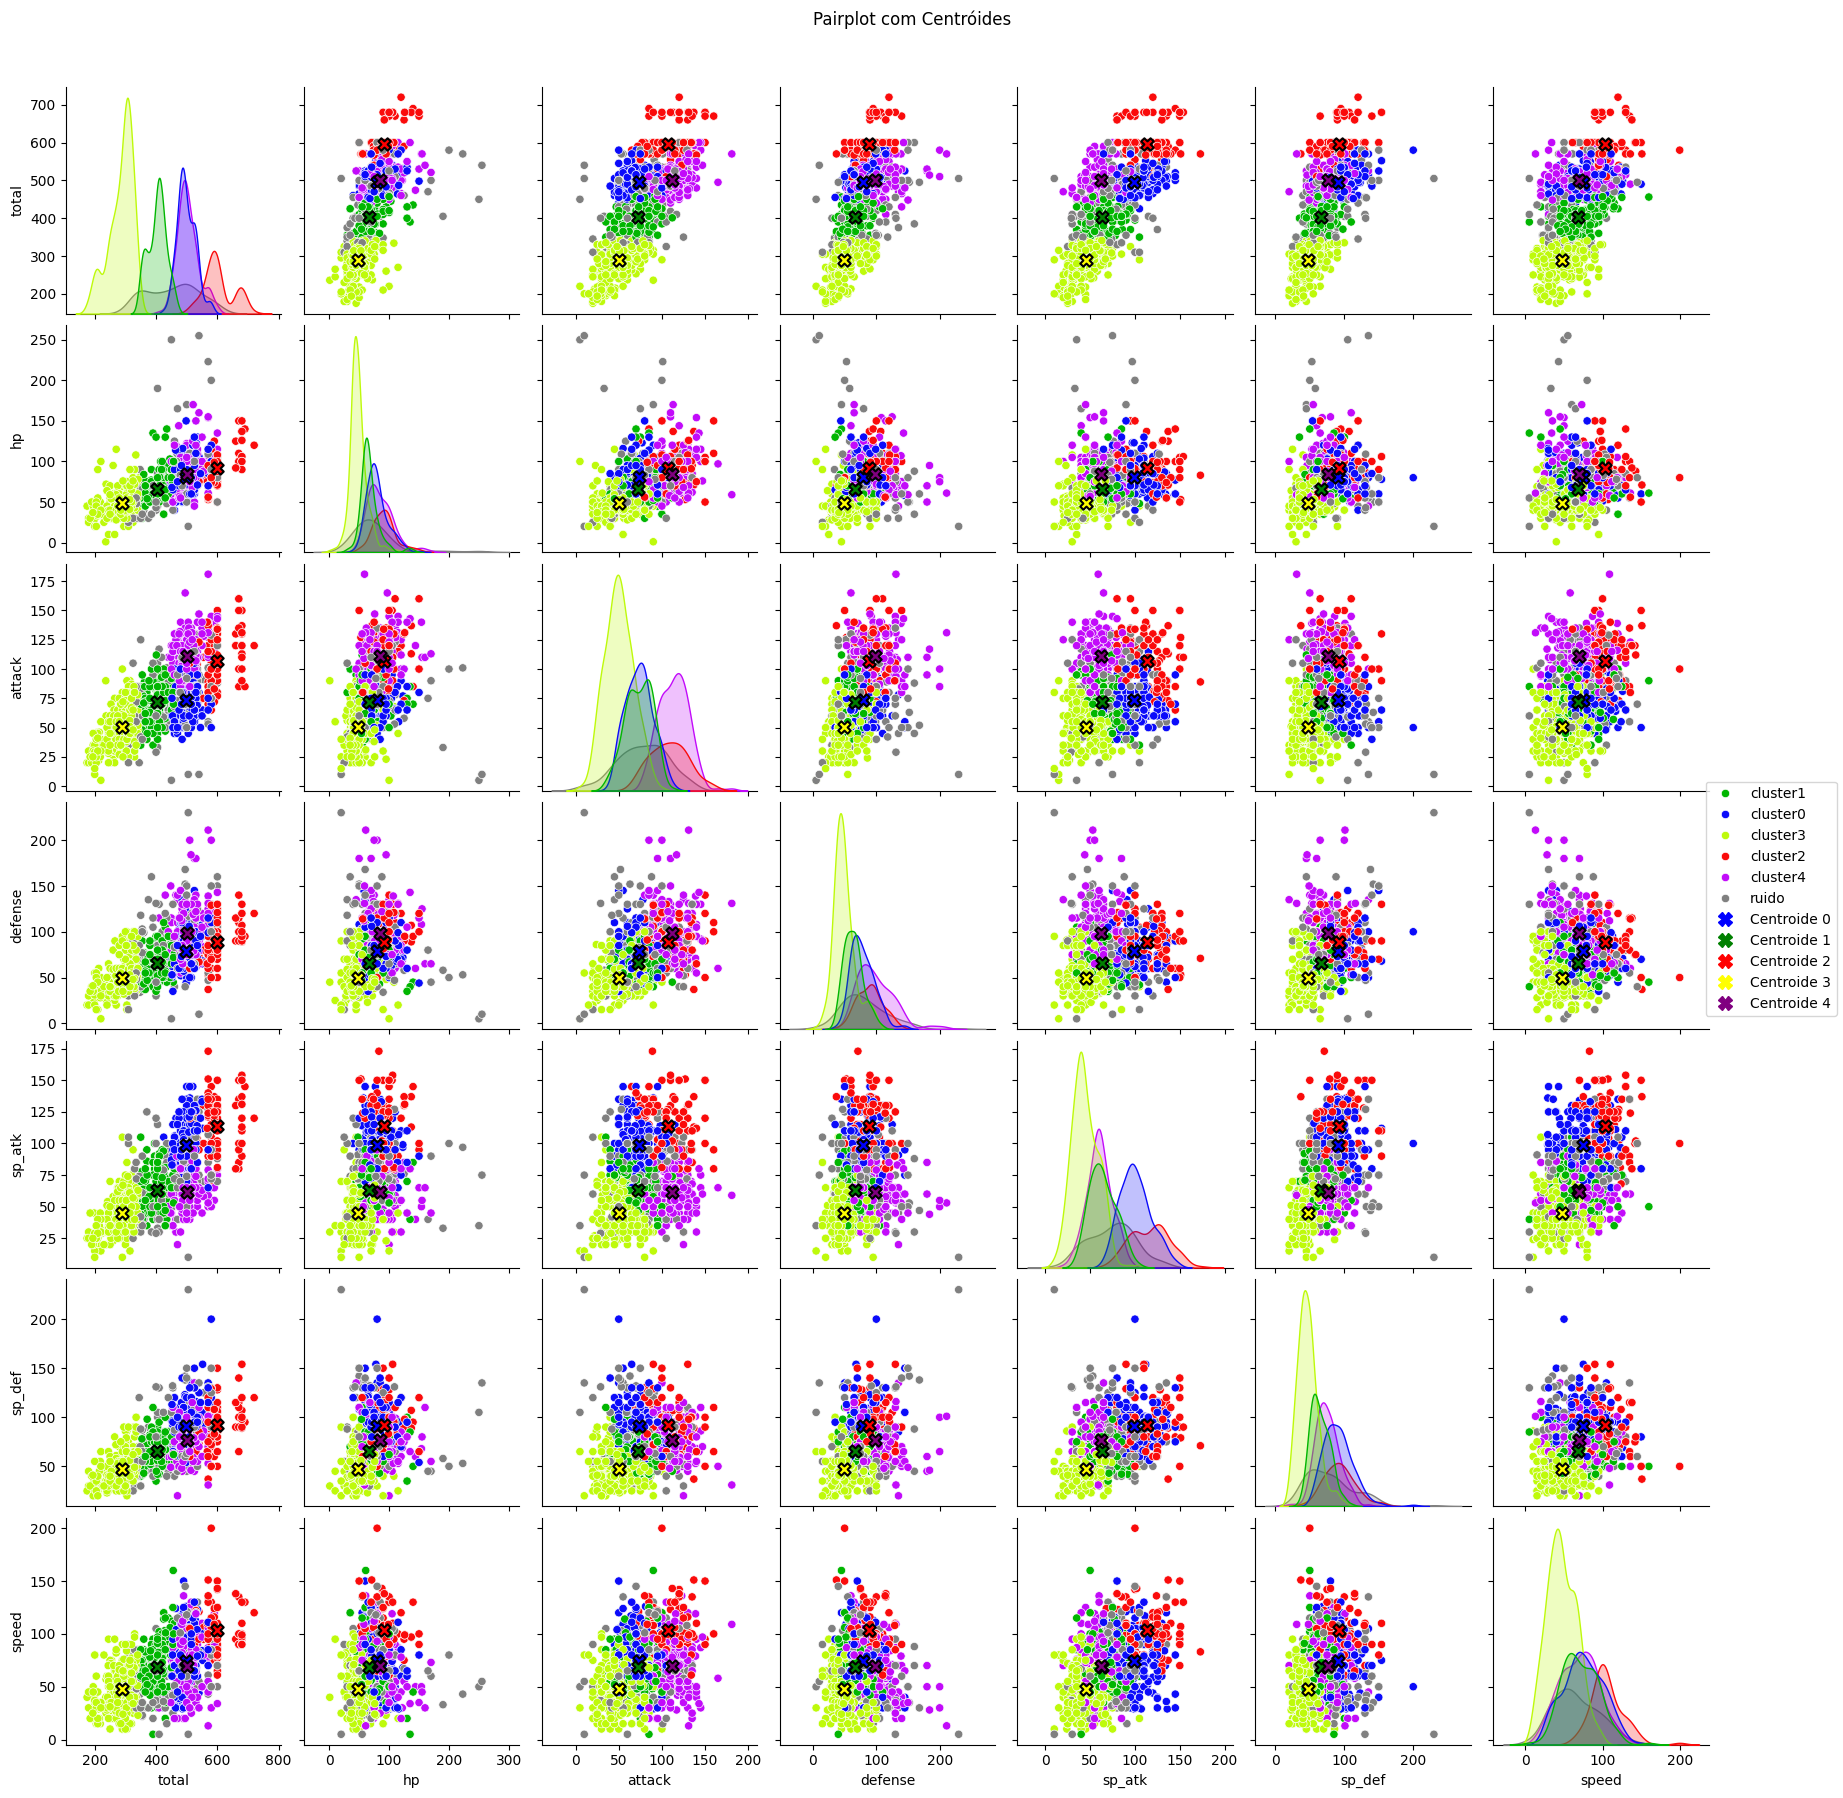

In [10]:
# Mostrando a separação de clusters, centroides e ruidos (zona de confusão)
df_plot = X.copy()
df_plot['classe'] = y

# Setando uma paleta de cores manualmente
palette = {
    'cluster0': "#0B0BFA",
    'cluster1': "#01B601",
    'cluster2': '#FA0B0B',
    'cluster3': "#BEFA0B",
    'cluster4': "#C20BFA",
    'ruido': 'gray'
}

g = sns.pairplot(df_plot, hue='classe', palette=palette, diag_kind='kde')

g.fig.suptitle("Pairplot com Centróides", y=1.03)

# Recuperando o scaler para inverter a normalização dos centroides
scaler = MinMaxScaler()
scaler.fit_transform(X)

centroides = scaler.inverse_transform(cent[-1])

cores_centroides = ['blue', 'green', 'red', 'yellow', 'purple']

for i, row in enumerate(g.axes):
    for j, ax in enumerate(row):
        if i == j:
            continue
        
        for k, c in enumerate(centroides):
            ax.scatter(
                c[j], c[i],
                c=cores_centroides[k],
                marker='X',
                s=80,
                edgecolors='black',
                linewidths=1.5
            )

handles = g._legend.legend_handles
labels = [t.get_text() for t in g._legend.texts]

for i, cor in enumerate(cores_centroides):
    handles.append(
        plt.Line2D(
            [0], [0],
            marker='X',
            color='w',
            markerfacecolor=cor,
            markeredgecolor=cor,
            markersize=10,
            label=f'Centroide {i}'
        )
    )
    labels.append(f'Centroide {i}')

g._legend.remove()
g.fig.legend(handles=handles, labels=labels, loc='center right', ncol=1)

plt.show()

# PCA

Variância explicada por componente:
[0.52034824 0.15793976 0.12602306]

Variância total explicada: 0.8043


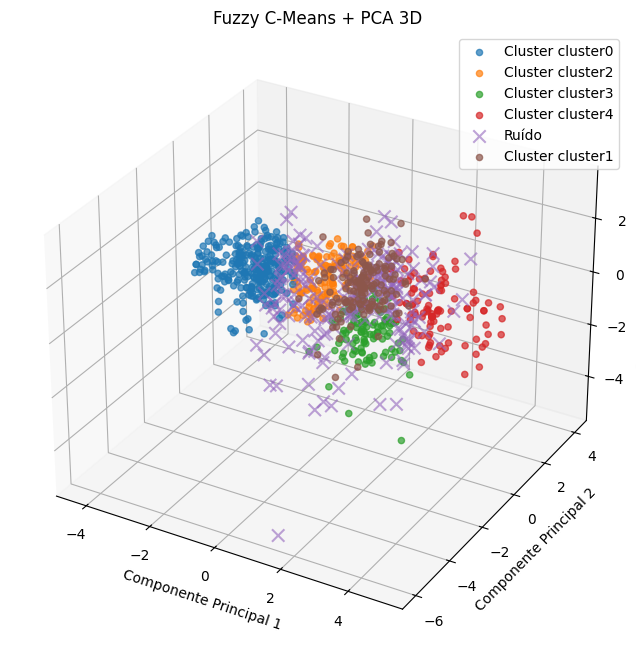

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from mpl_toolkits.mplot3d import Axes3D

# ===============================
# PCA para visualização 3D
# ===============================

# Padronizando os dados
std = StandardScaler()
X_std = std.fit_transform(X)

# Aplicando PCA com 3 componentes
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_std)

# Criando DataFrame para plot
df_plot = pd.DataFrame({
    'PCA1': X_pca[:, 0],
    'PCA2': X_pca[:, 1],
    'PCA3': X_pca[:, 2],
    'Cluster': y
})

# ===============================
# Plot 3D
# ===============================

fig = plt.figure(figsize=(12, 8))

ax = fig.add_subplot(111, projection='3d')

# Pegando clusters únicos
clusters = df_plot['Cluster'].unique()

for cluster in clusters:

    dados_cluster = df_plot[df_plot['Cluster'] == cluster]

    # Destacando ruídos
    if cluster == 'ruido':

        ax.scatter(
            dados_cluster['PCA1'],
            dados_cluster['PCA2'],
            dados_cluster['PCA3'],
            label='Ruído',
            alpha=0.6,
            marker='x',
            s=80
        )

    else:

        ax.scatter(
            dados_cluster['PCA1'],
            dados_cluster['PCA2'],
            dados_cluster['PCA3'],
            label=f'Cluster {cluster}',
            alpha=0.7
        )

# ===============================
# Configurações do gráfico
# ===============================

ax.set_title('Fuzzy C-Means + PCA 3D')

ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.set_zlabel('Componente Principal 3')

ax.legend()

print('Variância explicada por componente:')
print(pca.explained_variance_ratio_)

print(f'\nVariância total explicada: {pca.explained_variance_ratio_.sum():.4f}')

plt.show()

In [15]:
componentes = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=['PC1', 'PC2']
)
componentes

,hp,attack,defense,sp_atk,sp_def,speed
PC1,0.383051,0.469865,0.405731,0.452206,0.399486,0.322183
PC2,-0.090713,-0.138939,-0.609961,0.402236,-0.111879,0.652767


In [26]:
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import plotly.express as px

# ===============================
# Padronização
# ===============================

std = StandardScaler()
X_std = std.fit_transform(X)

# ===============================
# PCA com 3 componentes
# ===============================

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_std)

# ===============================
# DataFrame para visualização
# ===============================

df_plot = pd.DataFrame({
    'PCA1': X_pca[:, 0],
    'PCA2': X_pca[:, 1],
    'PCA3': X_pca[:, 2],
    'Cluster': y.astype(str),

    # Informações adicionais
    'Pokedex': df['num_pokedex'],
    'Nome': df['name'],
    'Tipo 1': df['type_1'],
    'Tipo 2': df['type_2'],
    'Total': df['total'],
    'HP': df['hp'],
    'Attack': df['attack'],
    'Defense': df['defense'],
    'Sp. Atk': df['sp_atk'],
    'Sp. Def': df['sp_def'],
    'Speed': df['speed']
})

# ===============================
# Plot 3D interativo
# ===============================

fig = px.scatter_3d(
    df_plot,
    x='PCA1',
    y='PCA2',
    z='PCA3',
    color='Cluster',
    hover_data={
        'Pokedex': True,
        'Nome': True,
        'Tipo 1': True,
        'Tipo 2': True,
        'Total': True,
        'HP': True,
        'Attack': True,
        'Defense': True,
        'Sp. Atk': True,
        'Sp. Def': True,
        'Speed': True,

        # Não mostrar duplicado
        'PCA1': False,
        'PCA2': False,
        'PCA3': False
    },
    opacity=0.7,
    title='Fuzzy C-Means + PCA 3D',
    width=1100,
    height=800
)

# Ajustando tamanho dos pontos
fig.update_traces(marker=dict(size=5))

# Layout
fig.update_layout(
    scene=dict(
        xaxis_title='Componente Principal 1',
        yaxis_title='Componente Principal 2',
        zaxis_title='Componente Principal 3'
    )
)

# ===============================
# Variância explicada
# ===============================

print('Variância explicada por componente:')
print(pca.explained_variance_ratio_)

print(f'\nVariância total explicada: {pca.explained_variance_ratio_.sum():.4f}')

# ===============================
# Exibindo gráfico
# ===============================

fig.show()

Variância explicada por componente:
[0.52034824 0.15793976 0.12602306]

Variância total explicada: 0.8043
